# Phase 1: Federated Causal Discovery Environment & Baseline
**Author**: MSc Project Student  
**Context**: This notebook provides a complete demonstration of the Phase 1 implementation for the Federated Causal Discovery thesis. It showcases:
1. The 10-variable Linear Gaussian Structural Causal Model (SCM).
2. The statistical verification of the overlapping v-structure using Fisher-Z tests.
3. The Graph Reinforcement Learning Markov Decision Process (MDP) using `gymnasium`.
4. The Centralized Double Deep Q-Network (DDQN) baseline training.


In [17]:
import sys
import os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Ensure src modules can be imported
module_path = os.path.abspath(os.path.join('.'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.scm.generator import LinearGaussianSCM
from src.scm.partition import partition_data
from src.tests.test_fisher_z import fisher_z_test
from src.rl.env import CausalDiscoveryEnv
from src.rl.agent import DDQNAgent
from src.rl.metrics import compute_shd


## Module 1: The SCM Data Generator
We initialize a 10-variable Linear Gaussian SCM. The global DAG specifically includes a v-structure $V_4 \rightarrow V_5 \leftarrow V_6$, where $V_5$ acts as a collider. In the federated setting (Phase 2), Agent 2 will observe $V_5, \dots, V_{10}$ but not $V_4$. Without communication, Agent 2 will suffer from relative latent confounding.


Global Data Shape: (2000, 10)
Agent 1 View: (2000, 6) (Variables 1-6)
Agent 2 View: (2000, 6) (Variables 5-10)


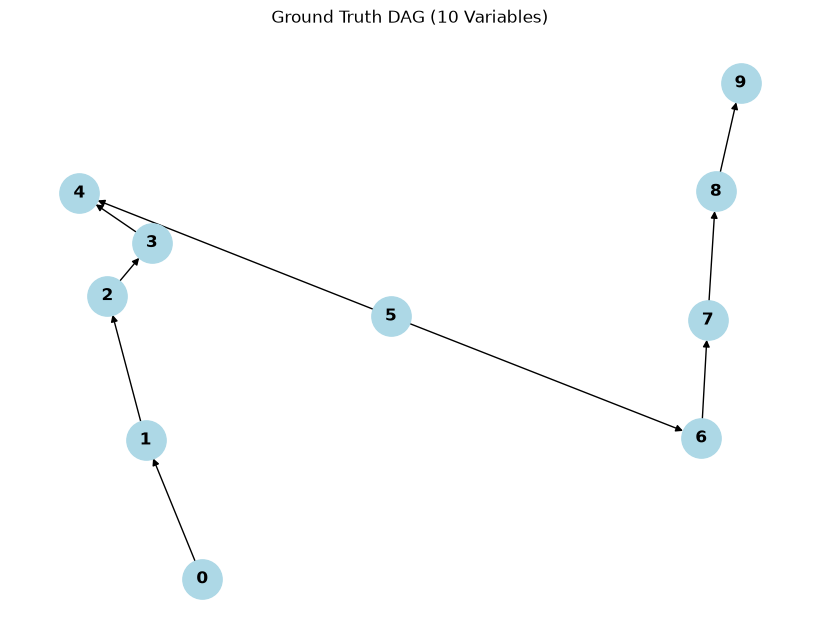

In [25]:
# Initialize SCM and generate dataset
scm = LinearGaussianSCM(num_vars=10, random_seed=42)
data = scm.generate_data(num_samples=2000, noise_std=1.0)

centralized, agent1, agent2 = partition_data(data)

print(f"Global Data Shape: {centralized.shape}")
print(f"Agent 1 View: {agent1.shape} (Variables 1-6)")
print(f"Agent 2 View: {agent2.shape} (Variables 5-10)")

# Visualize the Ground Truth DAG
G_true = nx.DiGraph(scm.adjacency_matrix)
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_true, seed=6)
nx.draw(G_true, pos, with_labels=True, node_color='lightblue', 
        node_size=800, font_size=12, font_weight='bold', arrows=True)
plt.title("Ground Truth DAG (10 Variables)")
plt.show()


### Statistical Verification of the Overlapping V-Structure
We must ensure that the dataset faithfully represents the causal graph before training RL agents. We use Fisher-Z conditional independence tests on the generated data.


In [19]:
v4, v5, v6 = 3, 4, 5 # 0-indexed

# Test 1: V4 and V6 should be marginally independent
is_indep_marginal, p_val, stat = fisher_z_test(centralized, v4, v6, z_indices=[])
print(f"V4 _|_ V6 -> Independent: {is_indep_marginal} (p-value: {p_val:.4f})")

# Test 2: V4 and V6 become dependent given the collider V5
is_indep_cond, p_val_cond, stat_cond = fisher_z_test(centralized, v4, v6, z_indices=[v5])
print(f"V4 _|_ V6 | V5 -> Independent: {is_indep_cond} (p-value: {p_val_cond:.4f})")


V4 _|_ V6 -> Independent: True (p-value: 0.9284)
V4 _|_ V6 | V5 -> Independent: False (p-value: 0.0000)


## Module 2: The MDP Environment
We frame the graph search as a discrete Markov Decision Process. 
The state is the current adjacency matrix. Actions are localized edits (`ADD`, `REMOVE`, `REVERSE`). The environment executes an acyclicity cycle-check mask at every step. The reward is derived from the differential Bayesian Information Criterion (BIC).


In [20]:
# Initialize the RL Environment
env = CausalDiscoveryEnv(data, max_steps=50, step_cost=0.05, lambda_sparse=0.1)
obs, info = env.reset()

print("Initial Environment State (Flattened Matrix):", obs.sum(), "edges")
print("Initial BIC Score:", info['bic'])

# Demonstrate Action Masking (Initial Graph is empty, so only ADD is valid)
mask = env.get_action_mask()
valid_actions = np.sum(mask)
total_actions = env.action_space.n
print(f"Valid Actions / Total Actions: {valid_actions} / {total_actions}")


Initial Environment State (Flattened Matrix): 0 edges
Initial BIC Score: 77528.31887426495
Valid Actions / Total Actions: 90 / 270


## Module 3: Centralized DDQN Agent Baseline
We train a Double Deep Q-Network on the centralized dataset. This establishes a performance ceiling. The agent's $\epsilon$-greedy policy strictly respects the environment's topological mask.


In [21]:
# Initialize Agent
agent = DDQNAgent(obs_size=100, action_size=env.action_space.n, lr=1e-3)

episodes = 30
best_bic = float('inf')
champion_dag = None
shd_history = []
reward_history = []

epsilon = 1.0

print("Starting DDQN Training Loop...")

for episode in range(episodes):
    obs, info = env.reset()
    mask = info['action_mask']
    done = False
    
    ep_reward = 0.0
    
    while not done:
        action = agent.select_action(obs, mask, epsilon)
        
        next_obs, reward, terminated, truncated, info = env.step(action)
        next_mask = info['action_mask']
        done = terminated or truncated
        
        agent.replay_buffer.push(obs, action, reward, next_obs, next_mask, done)
        agent.update(batch_size=32)
        
        ep_reward += reward
        obs = next_obs
        mask = next_mask
        
        if info['bic'] < best_bic:
            best_bic = info['bic']
            champion_dag = env.adjacency_matrix.copy()
            
    epsilon = max(0.05, epsilon * 0.90) # Decay
    
    if (episode + 1) % 5 == 0:
        agent.update_target_network()
        
    current_shd = compute_shd(champion_dag, scm.adjacency_matrix) if champion_dag is not None else 25
    shd_history.append(current_shd)
    reward_history.append(ep_reward)
    
    if (episode + 1) % 10 == 0:
        print(f"Episode {episode+1}/{episodes} | Total Reward: {ep_reward:.2f} | Best BIC: {best_bic:.2f} | Champion SHD: {current_shd}")

print("\nTraining Complete!")


Starting DDQN Training Loop...
Episode 10/30 | Total Reward: 1945.60 | Best BIC: 57039.13 | Champion SHD: 13
Episode 20/30 | Total Reward: 1872.26 | Best BIC: 57039.13 | Champion SHD: 13
Episode 30/30 | Total Reward: 1393.09 | Best BIC: 57039.13 | Champion SHD: 13

Training Complete!


### Training Convergence
The Structural Hamming Distance (SHD) should decrease as the agent learns the graph structure.


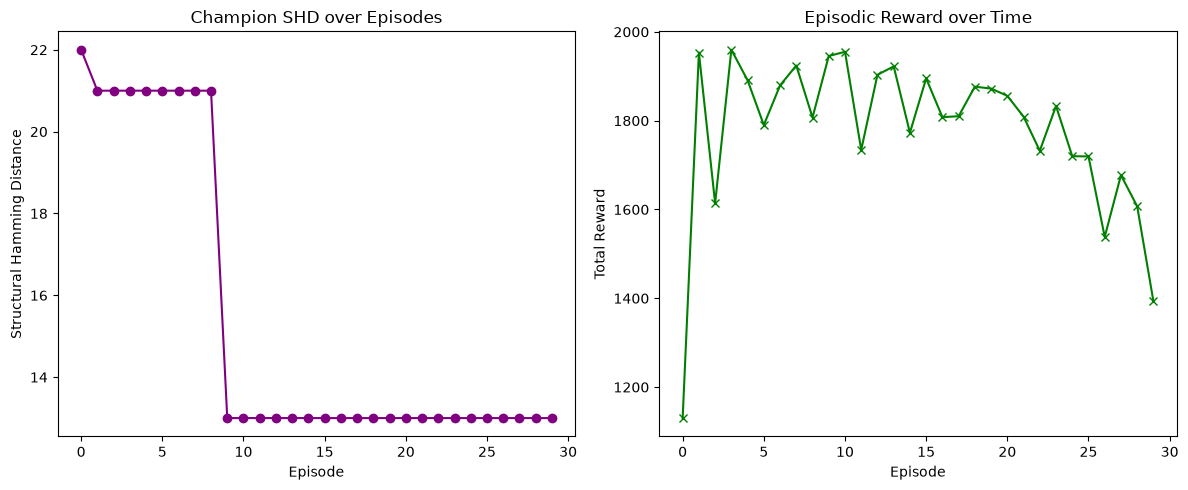

Final Structural Hamming Distance: 13


In [22]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(shd_history, color='purple', marker='o')
plt.title("Champion SHD over Episodes")
plt.xlabel("Episode")
plt.ylabel("Structural Hamming Distance")

plt.subplot(1, 2, 2)
plt.plot(reward_history, color='green', marker='x')
plt.title("Episodic Reward over Time")
plt.xlabel("Episode")
plt.ylabel("Total Reward")

plt.tight_layout()
plt.show()

final_shd = compute_shd(champion_dag, scm.adjacency_matrix)
print(f"Final Structural Hamming Distance: {final_shd}")


### Final Agent Graph vs Ground Truth
Let's visualize the graph discovered by the agent and compare it to the ground truth DAG.


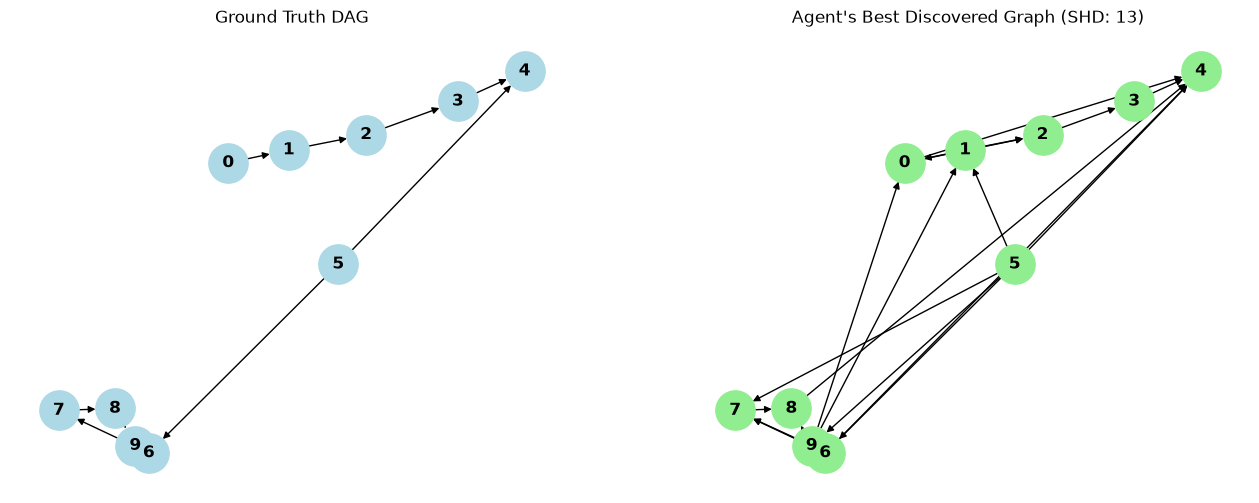

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ground Truth
G_true = nx.DiGraph(scm.adjacency_matrix)
pos = nx.spring_layout(G_true, seed=42)
nx.draw(G_true, pos, ax=axes[0], with_labels=True, node_color='lightblue', 
        node_size=800, font_size=12, font_weight='bold', arrows=True)
axes[0].set_title("Ground Truth DAG")

# Implied Graph (Champion)
G_implied = nx.DiGraph(champion_dag)
nx.draw(G_implied, pos, ax=axes[1], with_labels=True, node_color='lightgreen', 
        node_size=800, font_size=12, font_weight='bold', arrows=True)
axes[1].set_title(f"Agent's Best Discovered Graph (SHD: {final_shd})")

plt.show()
